In [11]:
import numpy as np
import matplotlib.pyplot as plt
import slmcontrol
from common.utils import generate_amplitude_and_phase_hologram, calculate_centroid, calculate_variance, remove_background, zoomfft2, fidelity
from custom_devices.custom_ximea import CustomXimea
import h5py
from pathlib import Path

In [12]:
N = 512
_xs = np.arange(N) - N // 2
_ys = np.arange(N) - N // 2
xs, ys = np.meshgrid(_xs, _ys)

Centroid: [255.40725032 251.23756359]
Fidelity: 0.9801979668144272


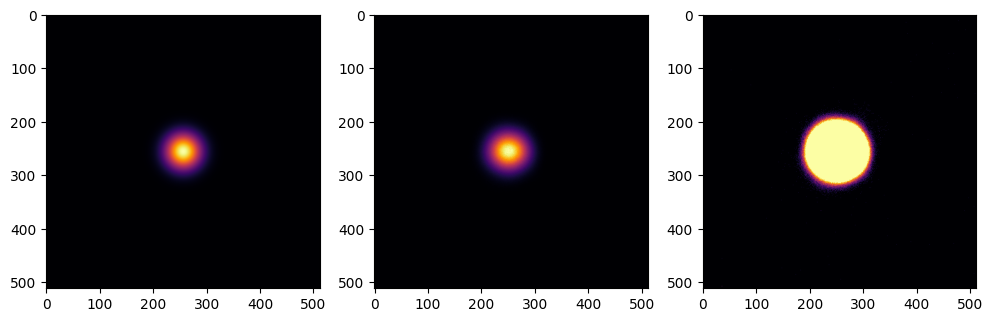

In [15]:
slm = slmcontrol.SLMDisplay(host="localhost")

try:
    with CustomXimea() as cam:
        W = 50
        BG = 4

        u = slmcontrol.hg(xs, ys, w=W)
        holo = generate_amplitude_and_phase_hologram(u, np.zeros_like(u), 192, 4, np.inf, slm_shape=(slm.height, slm.width // 2))
        slm.updateArray(holo)
        
        cam.set_exposure(15)
        calibration_image = cam.capture()
        cam.calibrate(N, image=calibration_image)

        image_experiment = remove_background(cam.capture(), BG)

        exp_variance = calculate_variance(image_experiment, 0)
        theo_variance = N**2 / 2 / np.pi**2 / W**2

        zoom = np.sqrt(exp_variance / theo_variance)

        ft_u = zoomfft2(u, zoom=zoom)
        image_theory = np.abs(ft_u)**2

        fig, axs = plt.subplots(1, 3, figsize=(12,8))


        axs[0].imshow(image_theory, cmap="inferno")
        axs[1].imshow(image_experiment, cmap="inferno")
        axs[2].imshow(image_experiment, cmap="inferno", vmax=10)

        print(f"Centroid: {calculate_centroid(image_experiment, 0.5)}",)
        print(f"Fidelity: {fidelity(ft_u, np.sqrt(image_experiment.astype(np.float64)))}")
finally:
    slm.close()

In [16]:
folder = Path("results") / Path("test")
folder.mkdir(parents=True, exist_ok=True)
with h5py.File(folder / "calibration.h5", "a") as f:
    f["N"] = N
    f["calibration_image"] = calibration_image
    f["zoom"] = zoom